# Case Study_Human Resourse Dataset

This project uses the human resoruces dataset to examine the potential attribution rate of employees based on the selected features.
This will also explore unsupervised learning techniques such as Kmeans clustering to compare different approaches.
The project also includes dimensionality reduction by applying principal component analysis (PCA) and building an autoencoder to complete reduction.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import seaborn as sns
%config InlineBackend.figure_format = 'retina' 

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

In [2]:
# Read the dataset and view data
employee_df = pd.read_csv('Human_Resources.csv')
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Show all the file data types
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Examine basic statistics
employee_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Visualize Dataset and Examine Relationships

In [5]:
# Encode 'Attrition','OverTime' and 'Over18' as integers
employee_df['Attrition'] = employee_df['Attrition'].map({'No': 0, 'Yes': 1})
employee_df['OverTime'] = employee_df['OverTime'].map({'No': 0, 'Yes': 1})
employee_df['Over18'] = employee_df['Over18'].map({'N': 0, 'Y': 1})

In [6]:
# Verify the updates are correct
employee_df[['Attrition', 'OverTime', 'Over18']]

,Attrition,OverTime,Over18
0,1,1,1
1,0,0,1
2,1,1,1
3,0,1,1
4,0,0,1
...,...,...,...
1465,0,0,1
1466,0,0,1
1467,0,1,1
1468,0,0,1


In [8]:
# Drop EmployeeNumber',EmployeeCount' ,'Standardhours' and 'Over18' since they do not change from one employee to the other
employee_df = employee_df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [10]:
# Examine some information related to the target/label, attrition
left_df        = employee_df[employee_df['Attrition'] == 1]
stayed_df      = employee_df[employee_df['Attrition'] == 0]

# Count the number of employees who stayed and left
# It seems that we are dealing with an imbalanced dataset
total = employee_df.shape[0]
left = left_df.shape[0]
stayed = stayed_df.shape[0]

print(f"Total = {total}")
print(f"Number of employees who left the company = {left}")
print(f"Percentage of employees who left the company = {left / total}%")
print(f"Number of employees who did not leave the company (stayed) = {stayed}")
print(f"Percentage of employees who did not leave the company (stayed) = {stayed / total}%")

Total = 1470
Number of employees who left the company = 237
Percentage of employees who left the company = 0.16122448979591836%
Number of employees who did not leave the company (stayed) = 1233
Percentage of employees who did not leave the company (stayed) = 0.8387755102040816%


In [11]:
# Heatmap requires numeric values
numeric_df = employee_df.select_dtypes(include=['number'])

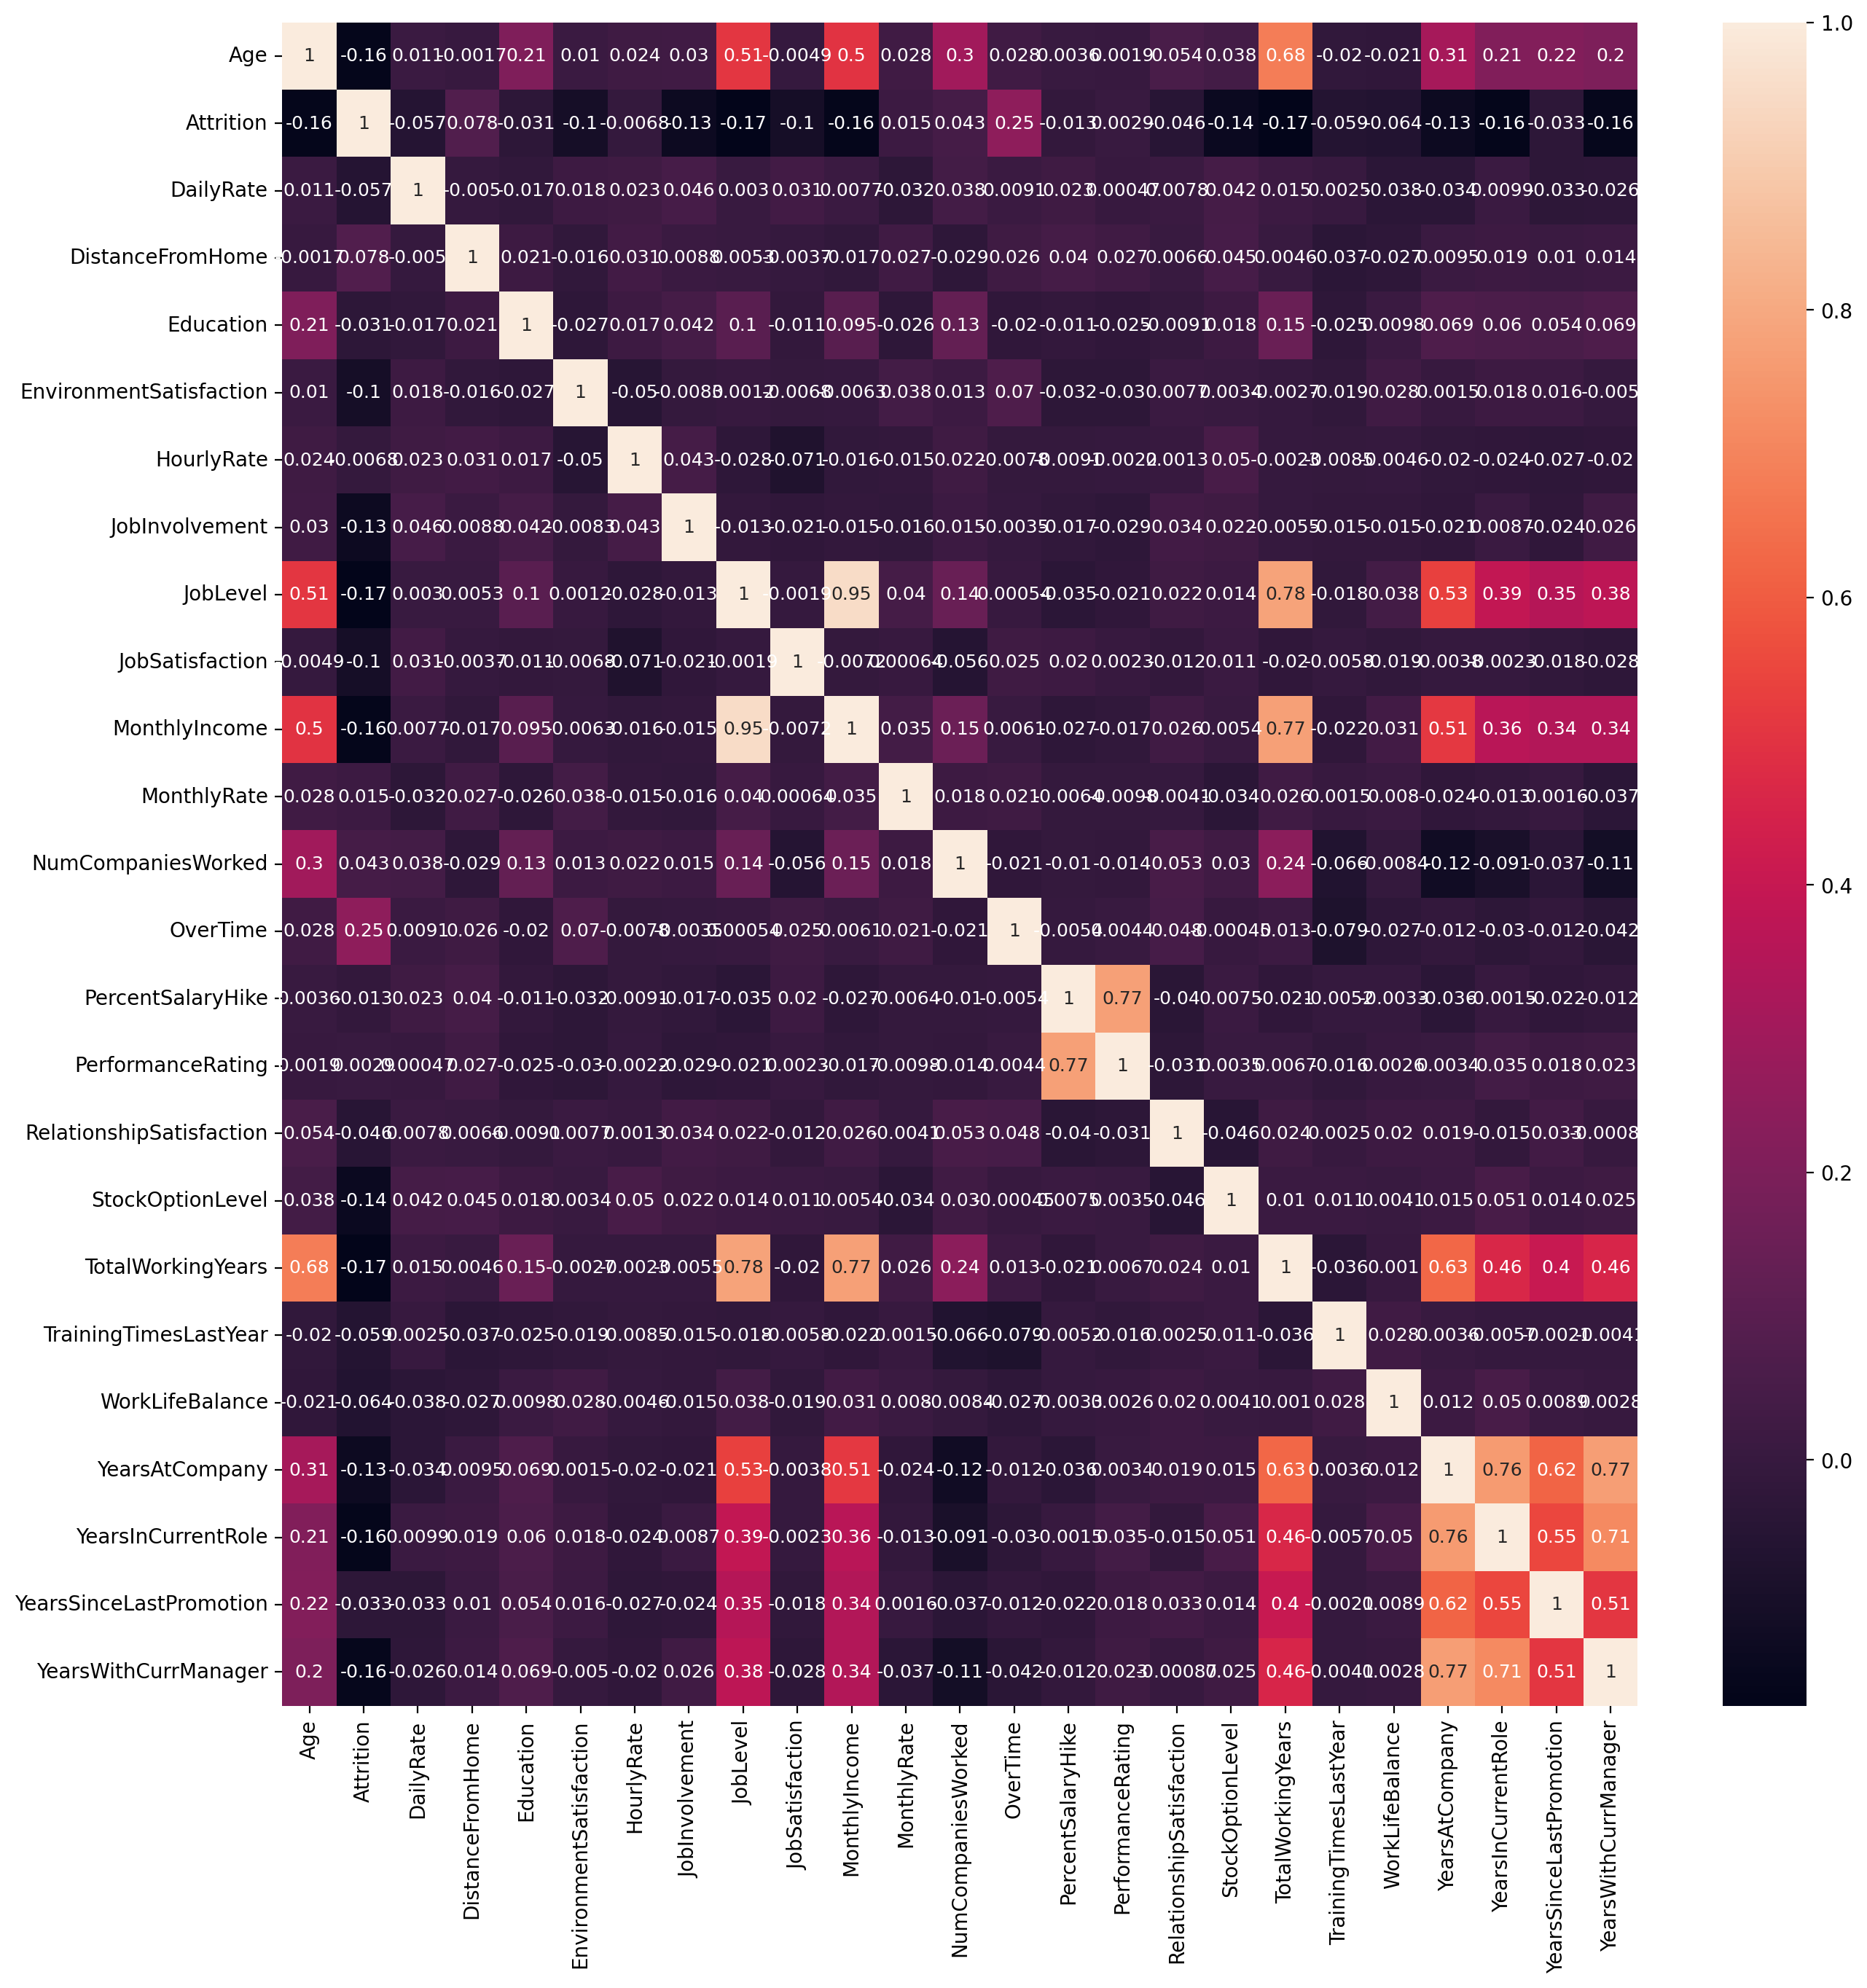

In [12]:
# Set larger canvas to avoid blurriness and squeezing
plt.figure(figsize=(15, 15))

# Plot the heatmap to visualize correlations
sns.heatmap(numeric_df.corr(), annot=True, annot_kws={"size": 9})
plt.show()

<Axes: xlabel='Age', ylabel='count'>

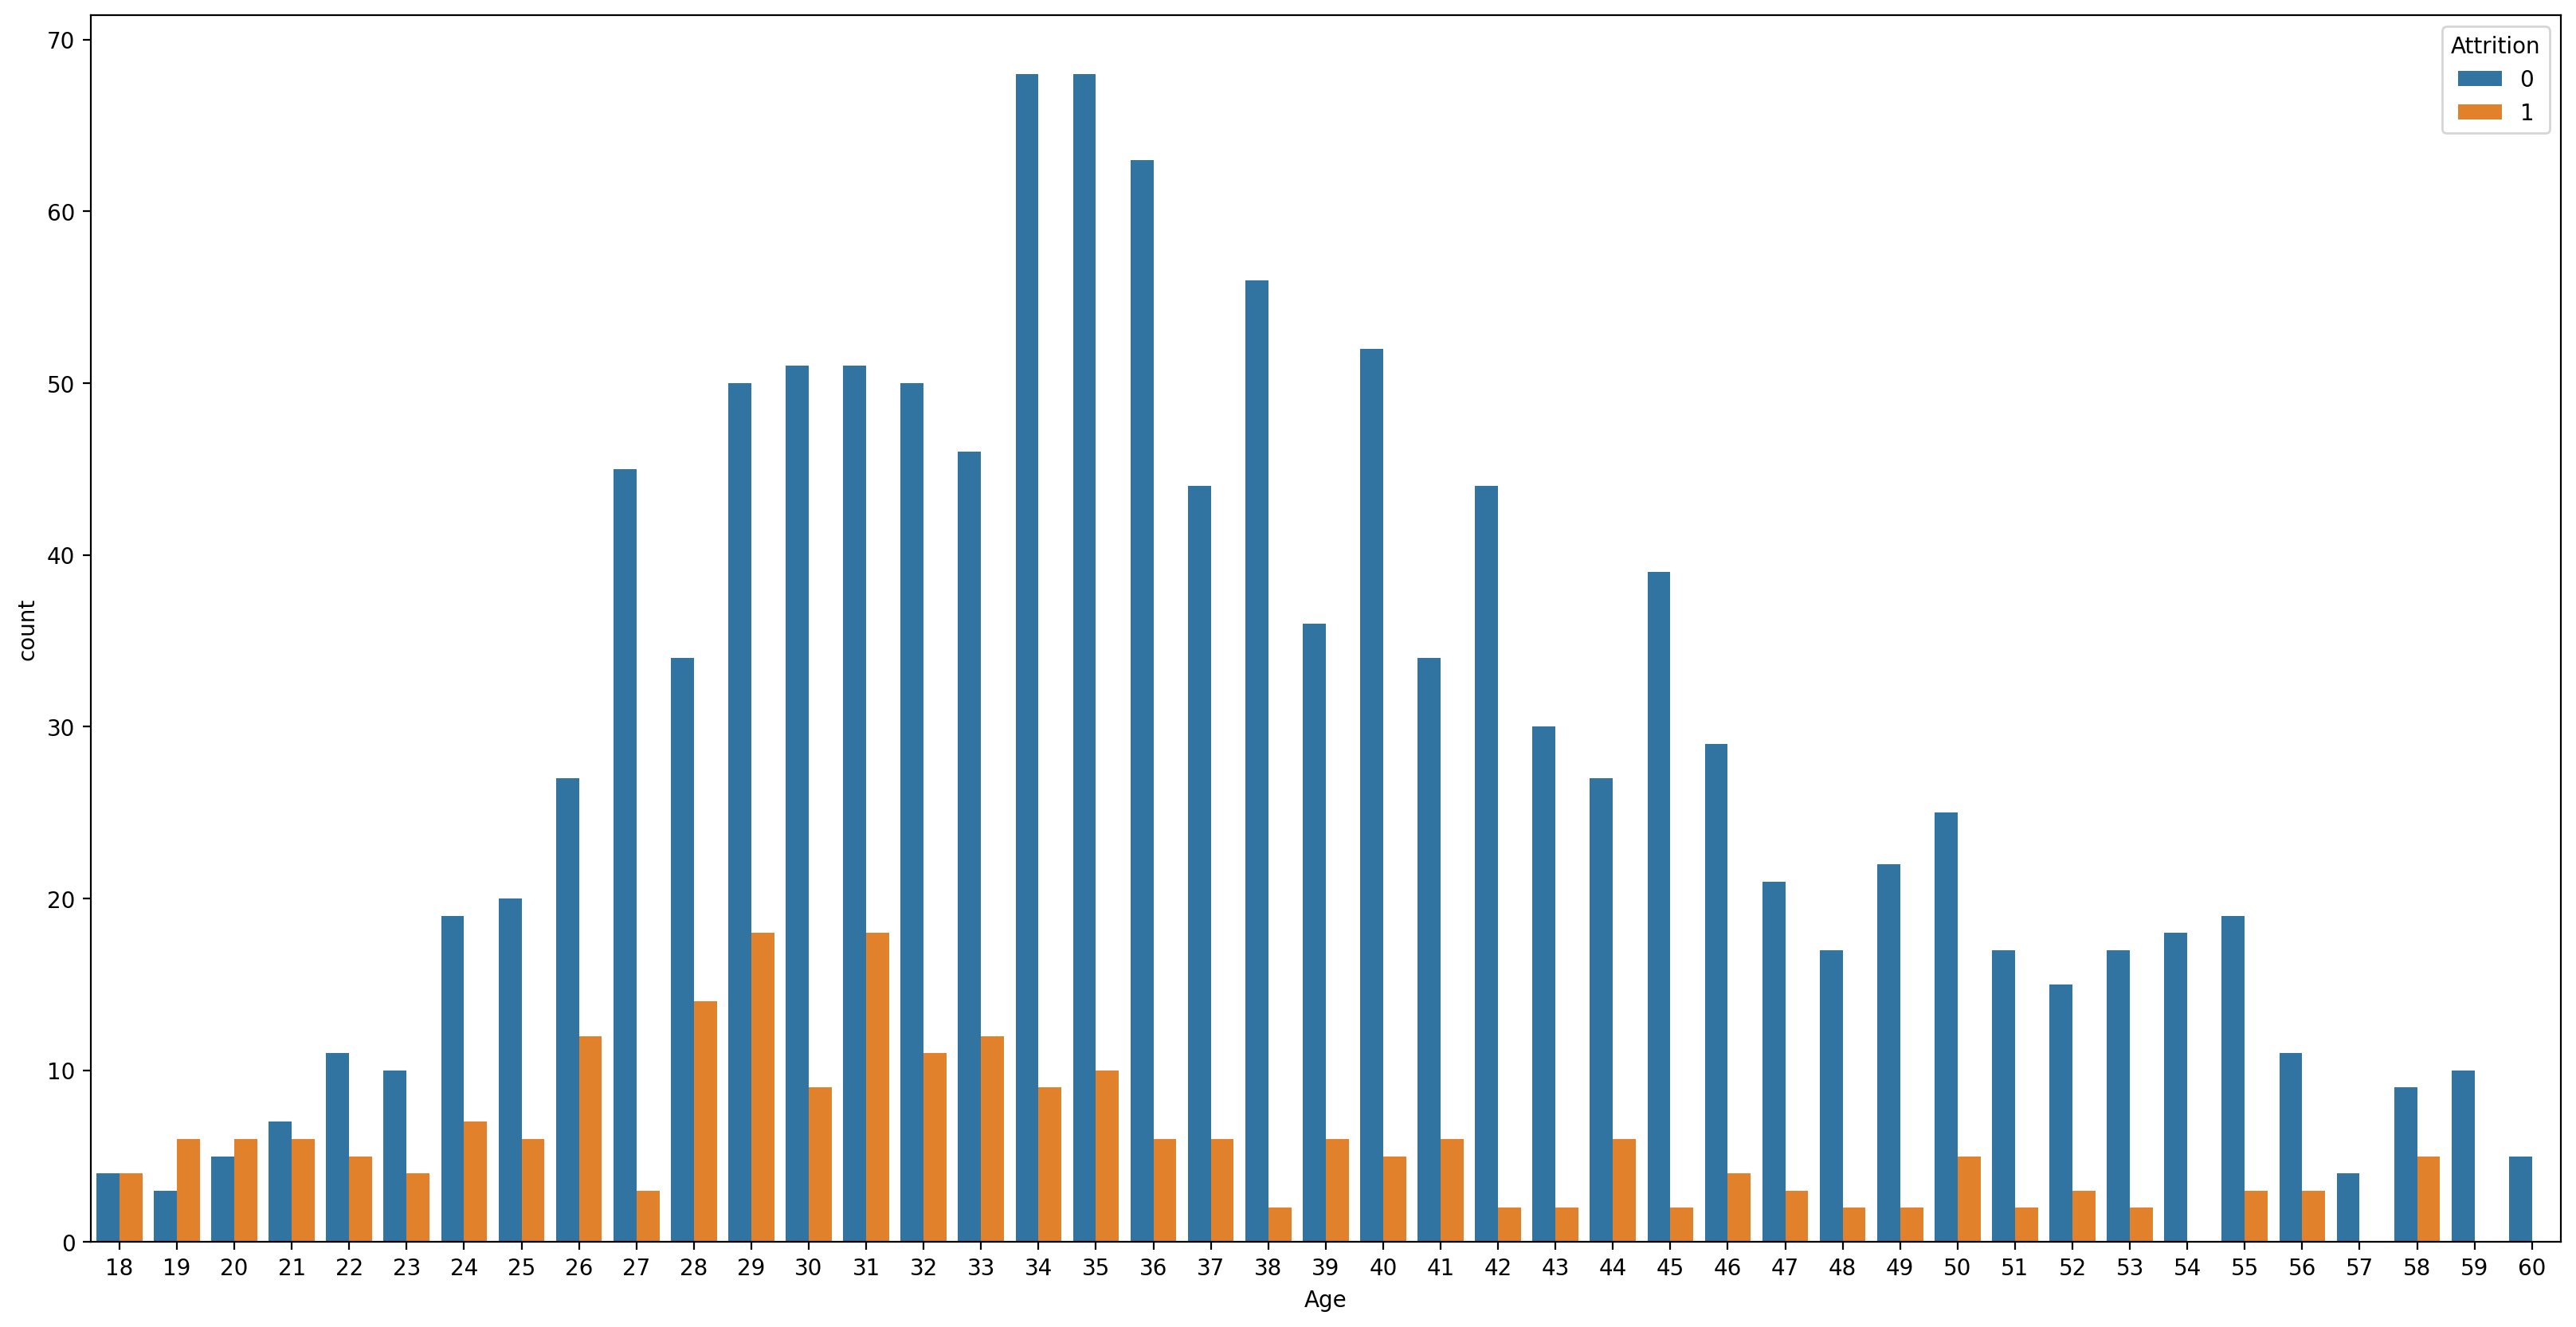

In [13]:
# Examine attribution distribution by age.
plt.figure(figsize=(20, 10))
sns.countplot(data=employee_df, x='Age', hue='Attrition')


<Axes: xlabel='DistanceFromHome', ylabel='Density'>

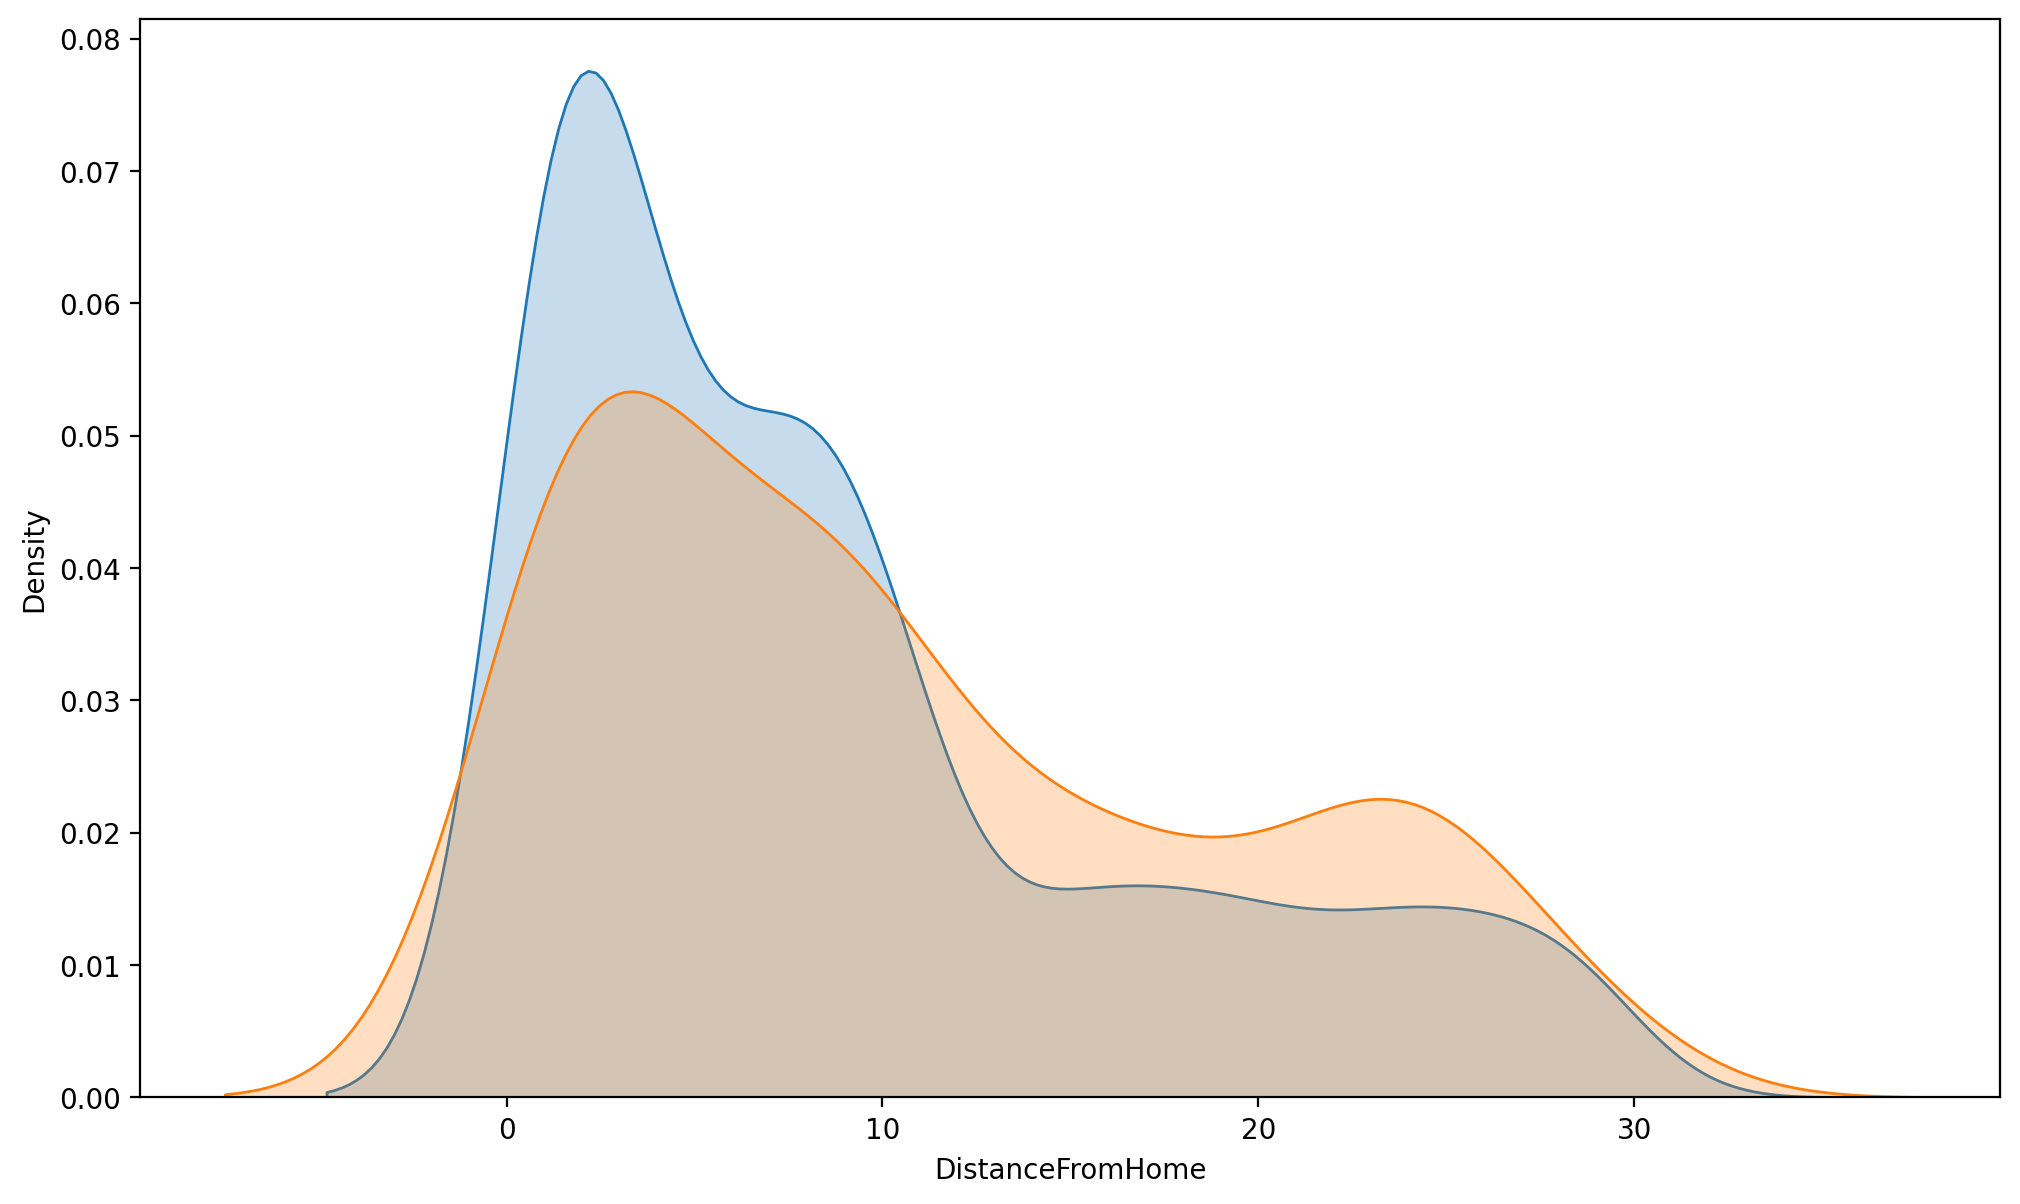

In [14]:
# Examine relationship between attrition and distance from home using a kernal density estimate.
plt.figure(figsize=(12,7))
sns.kdeplot(data=stayed_df, x='DistanceFromHome', fill=True)
sns.kdeplot(data=left_df, x='DistanceFromHome', fill=True)

<Axes: xlabel='MonthlyIncome'>

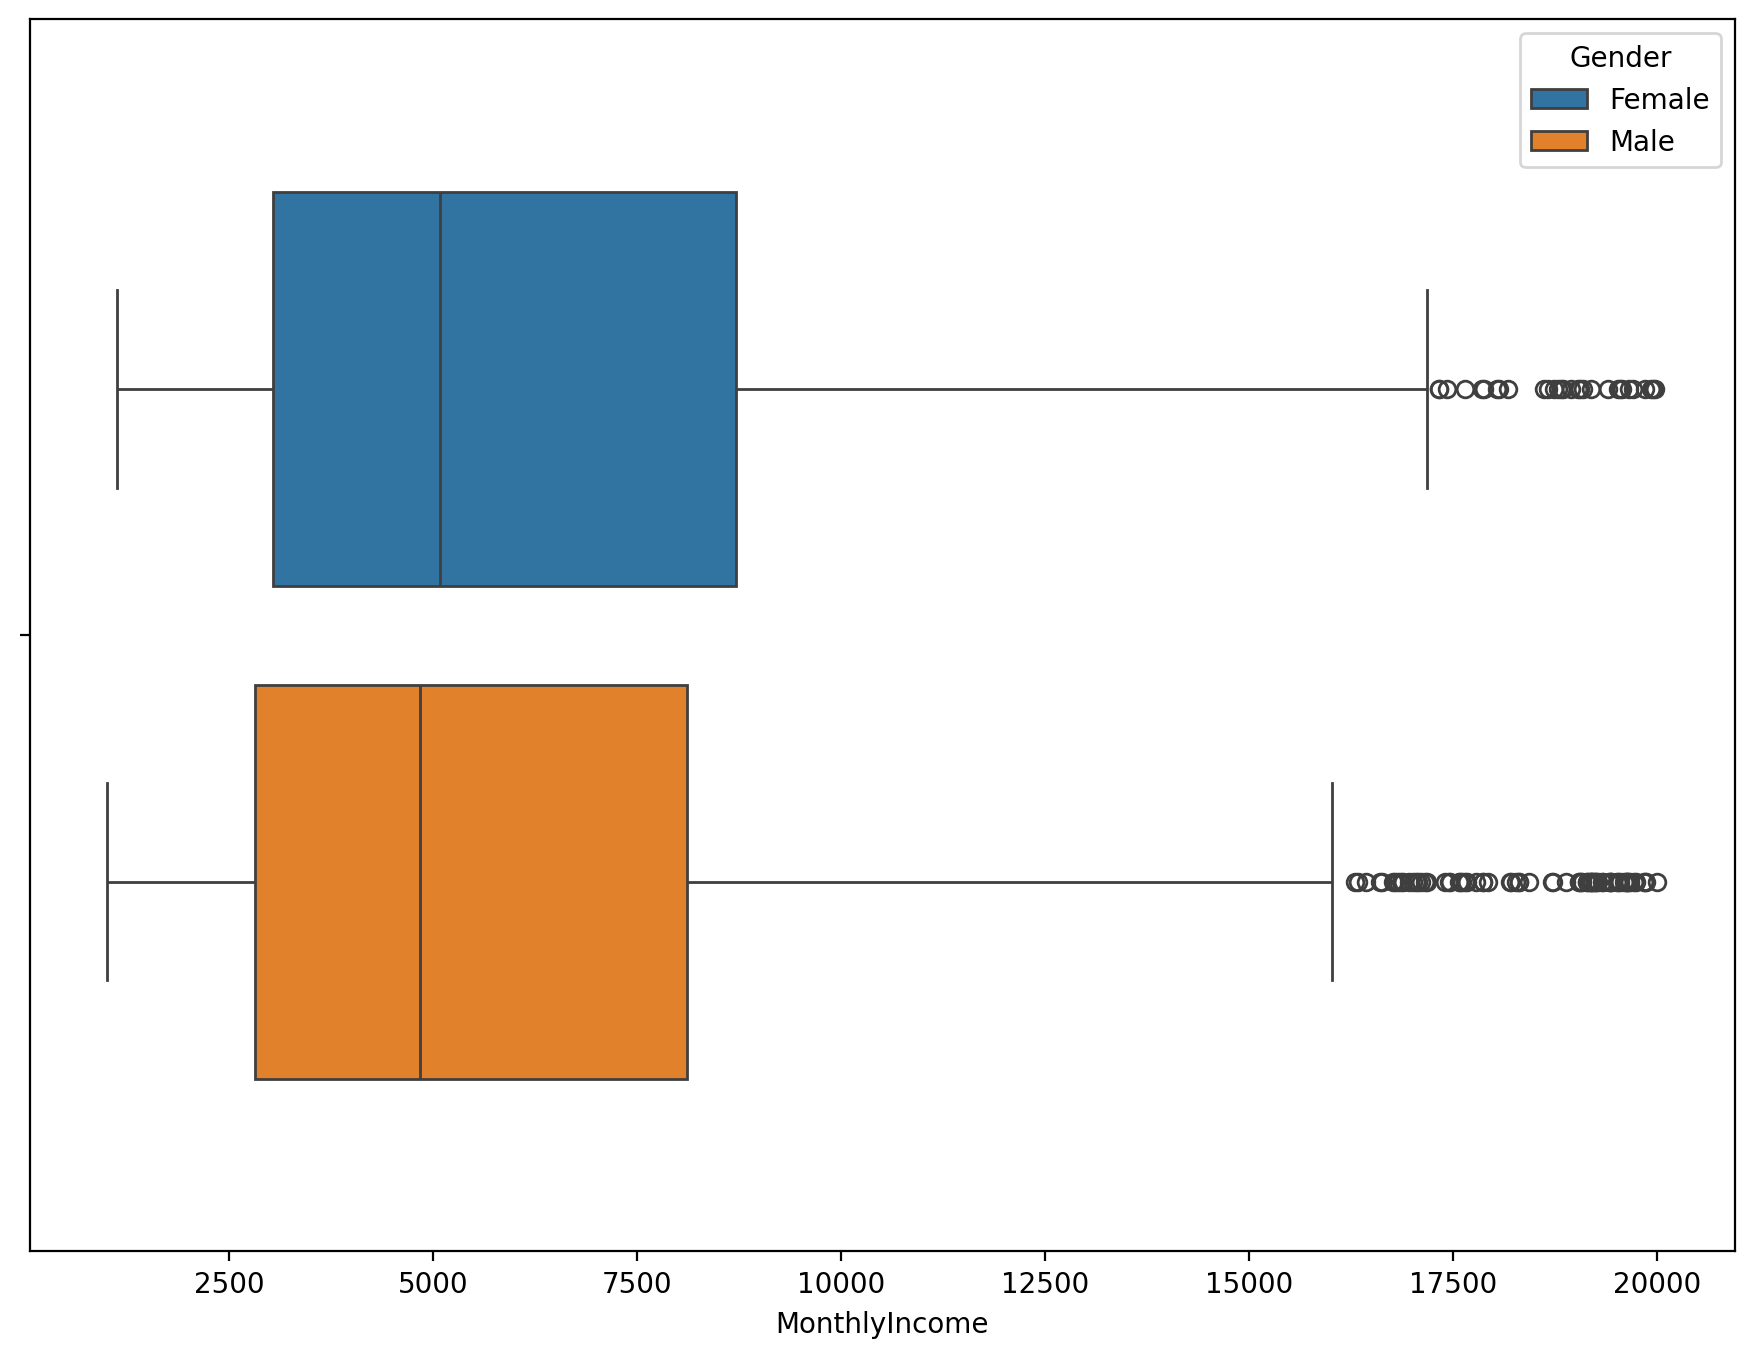

In [15]:
# Examine relationship between gender and monthly income.
plt.figure(figsize=(11, 8))
sns.boxplot(data=employee_df, x='MonthlyIncome', hue='Gender', gap=0.2)

## Create Testing and Training Dataset & Perform Data Cleaning

In [16]:
# Convert the categorical fields into numerics using OneHotEncoder
# Get the list of categorical columns first
cat_columns = employee_df.select_dtypes(include=['object']).columns.tolist()

# One-hot encoding for all categorical columns
employee_df = pd.get_dummies(
    employee_df,
    columns=cat_columns,
    drop_first=True,
    dtype=int
)

# Verify changes
employee_df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,92,2,1,3,...,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,40,3,1,2,...,0,1,0,0,0,0,0,0,1,0


In [17]:
# Verify dtypes
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [18]:
# Select features
features = employee_df.drop(columns=['Attrition'])
features

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,0,1,0,0,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,0,0,0,1,0,0,1,0
2,37,1373,2,2,4,92,2,1,3,2090,...,0,1,0,0,0,0,0,0,0,1
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,0,1,0,0,1,0
4,27,591,2,1,1,40,3,1,2,3468,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,0,1,0,0,0,0,0,0,1,0
1466,39,613,6,1,4,42,2,3,1,9991,...,0,0,0,0,0,0,0,0,1,0
1467,27,155,4,3,2,87,4,2,2,6142,...,0,0,0,1,0,0,0,0,1,0
1468,49,1023,2,3,4,63,2,2,2,5390,...,0,0,0,0,0,0,1,0,1,0


In [19]:
# Scale features data 
scaler = MinMaxScaler()
X = scaler.fit_transform(features)
X

array([[0.54761905, 0.71581961, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.73809524, 0.12670007, 0.25      , ..., 0.        , 1.        ,
        0.        ],
       [0.45238095, 0.90980673, 0.03571429, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.21428571, 0.03793844, 0.10714286, ..., 0.        , 1.        ,
        0.        ],
       [0.73809524, 0.65926986, 0.03571429, ..., 0.        , 1.        ,
        0.        ],
       [0.38095238, 0.37652112, 0.25      , ..., 0.        , 1.        ,
        0.        ]])

In [20]:
# Select target variable ('Attrition')
y = employee_df['Attrition']
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

## Find the Optimal Number of Clusters using Elblow Method

In [21]:
# Compute 'within cluster sum of squares' or WCSS metric for a range of k clusters
k = 10 # Can be changed as needed.

wcss_vals = []
for i in range(1, k + 1):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 498)
    kmeans.fit(X)
    wcss_vals.append(kmeans.inertia_) # Calculates the WCSS value

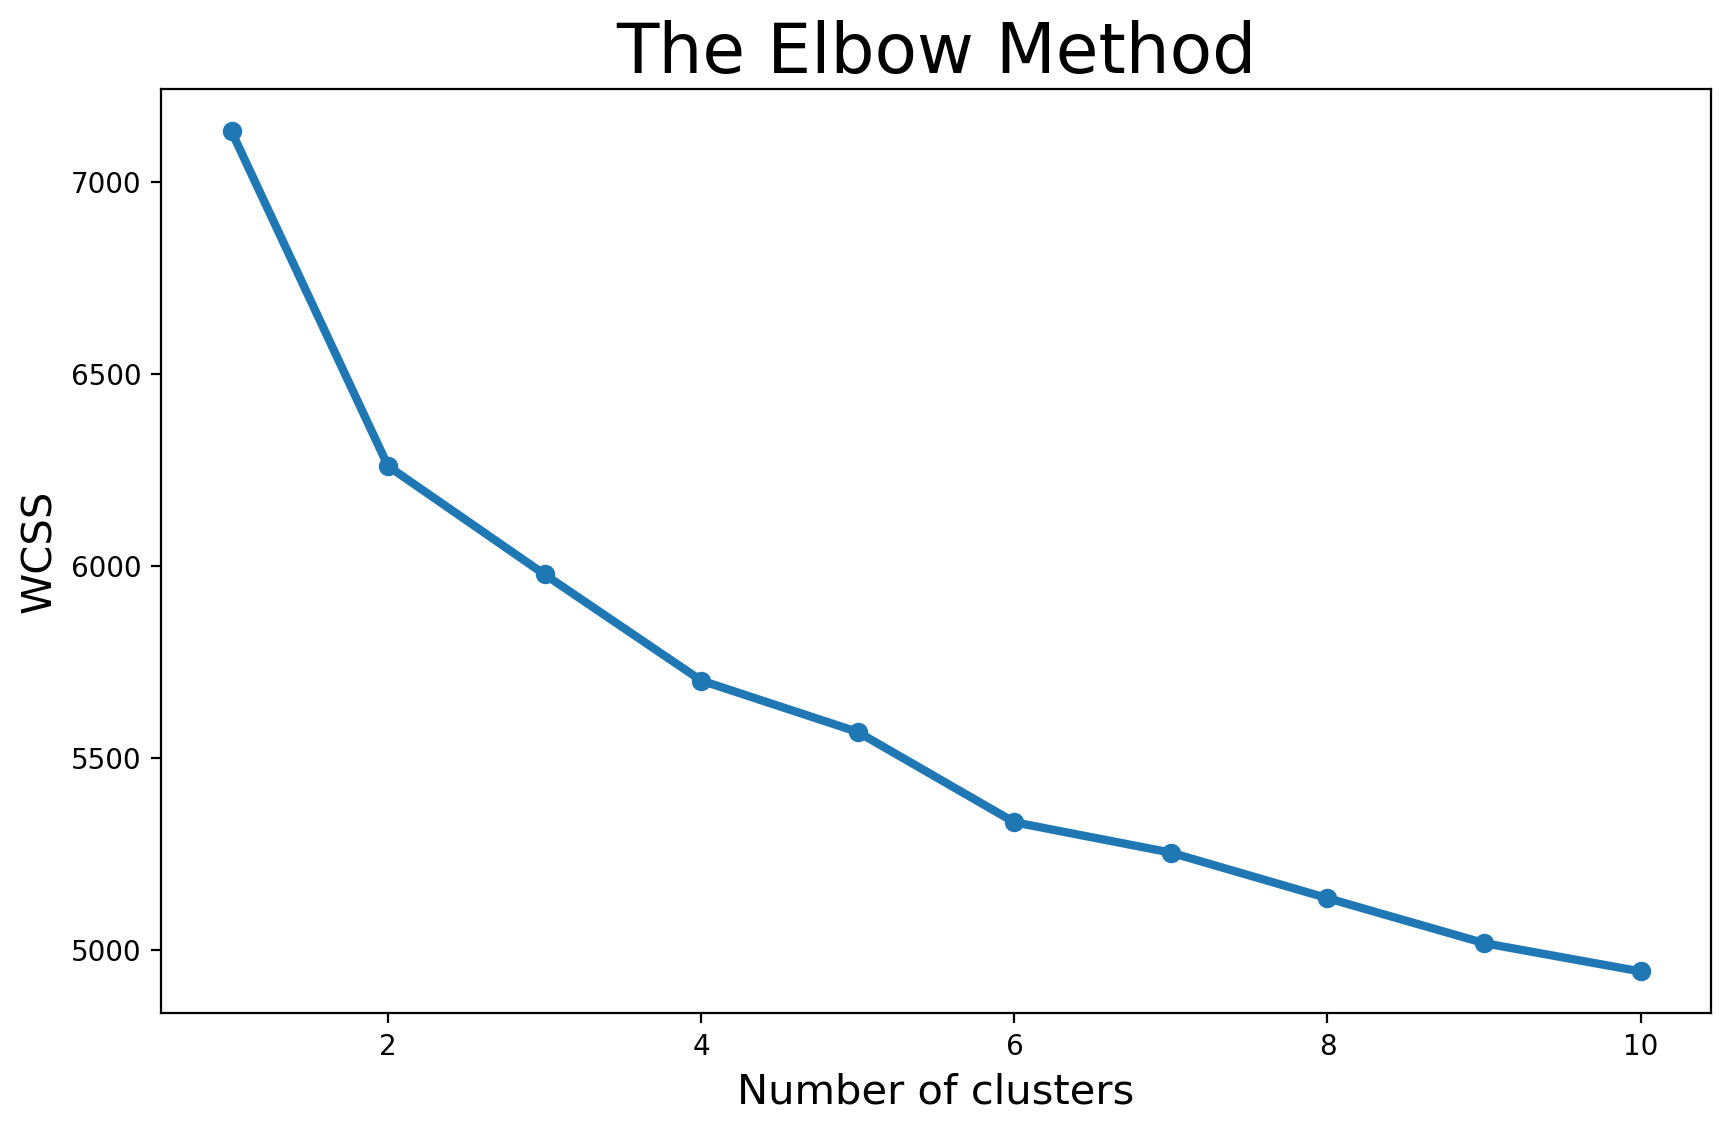

In [22]:
# Create a visualization for Finding the right number of clusters - Elbow method'
plt.figure(figsize = (10,6))
plt.plot(range(1, k + 1), wcss_vals, lw = 3, marker='o')
plt.title('The Elbow Method', fontsize = 25)
plt.xlabel('Number of clusters', fontsize = 15)
plt.ylabel('WCSS', fontsize =15 )
plt.show()

## Apply K-Means Clustering

In [23]:
# Initialize the model with "elbow" value
k_means_model = KMeans(n_clusters=4, random_state= 498)
k_means_model.fit(X)

KMeans(n_clusters=4, random_state=498)

In [24]:
# See which points are assigned to which cluster
cluster_label = k_means_model.labels_
feature_copy = features.copy()
feature_copy['cluster'] = pd.DataFrame({'cluster': cluster_label})
feature_copy.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,cluster
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,0,0,1,0,0,1,0,2
2,37,1373,2,2,4,92,2,1,3,2090,...,1,0,0,0,0,0,0,0,1,2
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,1,0,0,1,0,2
4,27,591,2,1,1,40,3,1,2,3468,...,1,0,0,0,0,0,0,1,0,3


In [25]:
# Check size of each cluster to assess if they are all representative
values, counts = np.unique(cluster_label, return_counts=True)

for i in range(len(values)):
    print(f"Cluster: {values[i]}, Count: {counts[i]}")

Cluster: 0, Count: 207
Cluster: 1, Count: 414
Cluster: 2, Count: 538
Cluster: 3, Count: 311


### Based on size breakdown shown above, each cluster has proper representation.

## Apply PCA and Visualize Results


In [26]:
# Obtain the principal components
pca = PCA()

# Apply PCA to the scaled features
x_pca = pca.fit_transform(X)
x_pca

array([[-1.12383044, -0.87335486,  0.50067796, ..., -0.00240038,
         0.00602315,  0.00604865],
       [ 0.65520972,  0.27534626,  0.8494961 , ..., -0.00457607,
        -0.02227099, -0.00267146],
       [ 0.60949304, -0.78518814, -0.2801749 , ..., -0.00749136,
        -0.02720532,  0.00217979],
       ...,
       [ 0.530395  ,  0.58440489,  0.73535265, ...,  0.01036841,
         0.01355588,  0.00636939],
       [-1.0940503 ,  0.37991827, -0.55360185, ..., -0.01703525,
        -0.02408092, -0.00329423],
       [ 0.63576418,  0.65611512, -0.65285363, ..., -0.0102328 ,
        -0.04918131,  0.01035031]])

In [27]:
# All samples projected on the two principal components
first_pc = x_pca[:, 0]
second_pc = x_pca[:, 1]

print(f"First Principal Component: {first_pc}")
print(f"Second Principal Component: {second_pc}")

First Principal Component: [-1.12383044  0.65520972  0.60949304 ...  0.530395   -1.0940503
  0.63576418]
Second Principal Component: [-0.87335486  0.27534626 -0.78518814 ...  0.58440489  0.37991827
  0.65611512]


In [28]:
# Create a dataframe with the two components
pca_df = pd.DataFrame({'first_pc': first_pc, 'second_pc': second_pc})
pca_df.head()

,first_pc,second_pc
0,-1.123830,-0.873355
1,0.655210,0.275346
2,0.609493,-0.785188
3,0.627981,0.122222
4,0.671010,0.649352


In [29]:
# Concatenate the clusters labels to the dataframe
pca_df['cluster'] = pd.DataFrame(cluster_label)
pca_df.head()

,first_pc,second_pc,cluster
0,-1.123830,-0.873355,1
1,0.655210,0.275346,2
2,0.609493,-0.785188,2
3,0.627981,0.122222,2
4,0.671010,0.649352,3


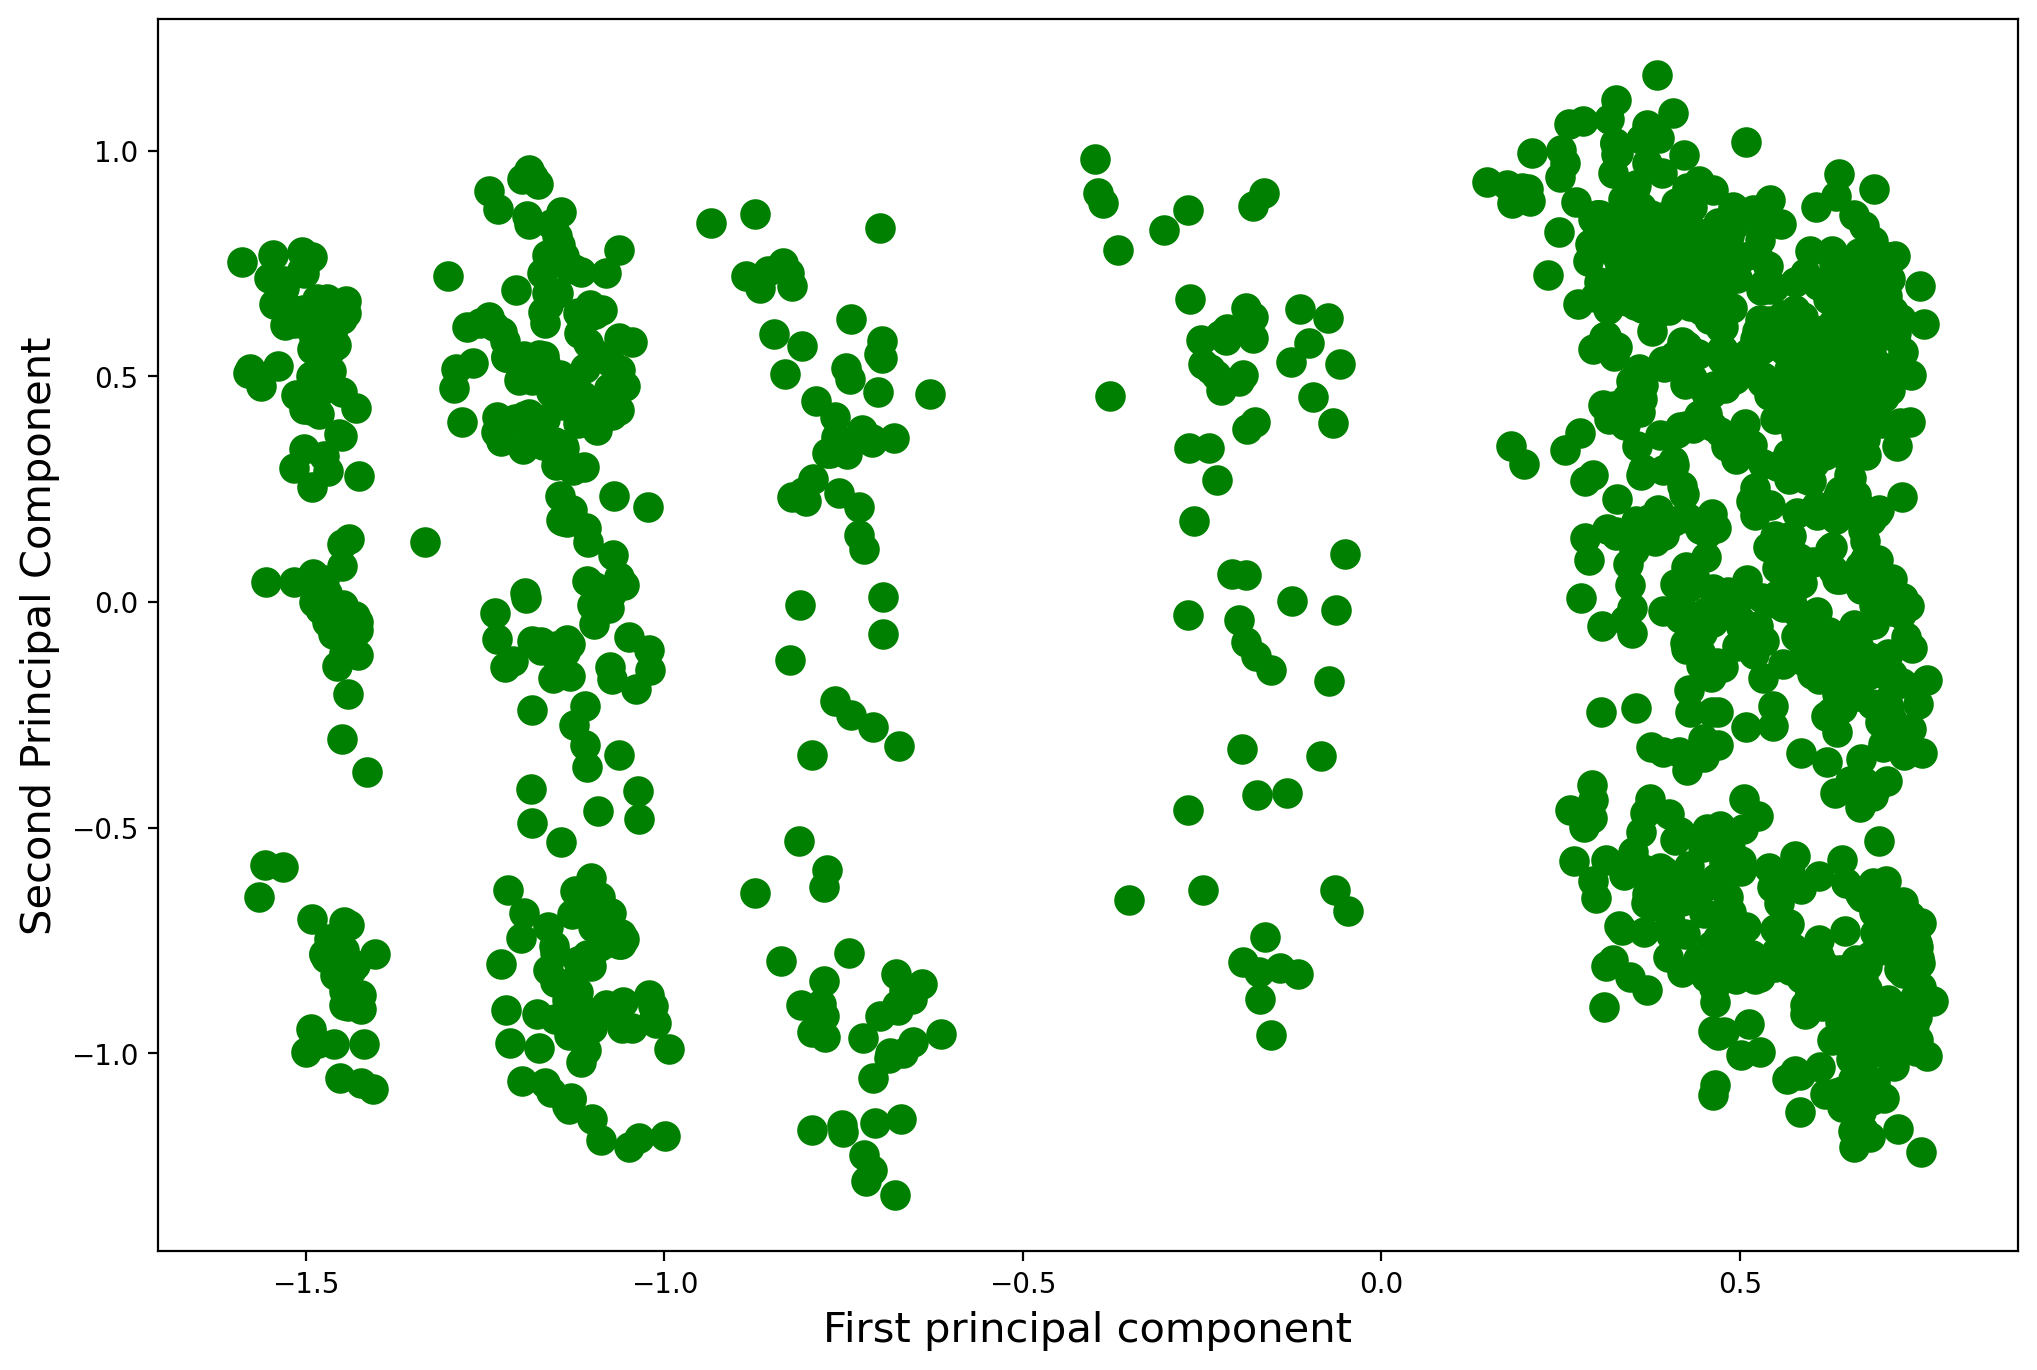

In [30]:
# Scatterplot visual of Projection of the dataset on the 2 PCA dimensions'
plt.figure(figsize=(12, 8))
plt.scatter(pca_df['first_pc'], pca_df['second_pc'], s = 100, c = 'g', label='attrition')
plt.xlabel('First principal component', fontsize = 15)
plt.ylabel('Second Principal Component', fontsize = 15)
plt.show()

In [31]:
# show the % of the total variance explained by each principal component.
explained_variance_ratio = pca.explained_variance_ratio_
first_two_explained_variance_ratio = explained_variance_ratio[0] + explained_variance_ratio[1]
total_explained_variance_ratio = explained_variance_ratio.sum()

# Report findings
print(f"\nExplained Variance Ratio:\n{explained_variance_ratio}")
print(f"\nExplained Variance Ratio of First Two Components:\n{first_two_explained_variance_ratio}")
print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")


Explained Variance Ratio:
[0.1313545  0.08540412 0.07465617 0.06493033 0.05863151 0.04984688
 0.04318494 0.03784399 0.03685631 0.03022081 0.02809944 0.02655002
 0.02612237 0.02405859 0.02247465 0.02075598 0.01995275 0.01830754
 0.01770455 0.01710631 0.01622091 0.01508134 0.01318989 0.0131414
 0.01260639 0.01150693 0.01118576 0.01083612 0.01064962 0.00913553
 0.00851079 0.00637868 0.00588204 0.00491608 0.00400779 0.00365612
 0.00240816 0.0022945  0.00128727 0.00088206 0.00083704 0.00055549
 0.00046598 0.00030236]

Explained Variance Ratio of First Two Components:
0.21675861576851121
Total Explained Variance Ratio: 1.0000


## Perform Dimensionality Reduction using Autoencoders

In [34]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=498, stratify=y)

In [35]:
# Specify the input dimensions first
input_dim = X_train.shape[1]

# Specify the size of hidden layer
hidden_dim = 32

# Specify the size of latent layer
latent_dim = 24

In [36]:
# Define the layers in the full autoencoder system
# Encoder, bottleneck/latent_space, decoder, autoencoder (whole system)
input_layer = Input(shape=(input_dim,))
encoded = Dense(hidden_dim, activation='relu')(input_layer)
latent_space = Dense(latent_dim, activation='relu')(encoded)
decoded = Dense(hidden_dim, activation='relu')(latent_space)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# Defines the entire model composed of these layers.
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [37]:
# Examine autoencoder summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 44)             │         1,452 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,484 (17.52 KB)

 Trainable params: 4,484 (17.52 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
## Train autoencoder using input = output
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_split=0.2)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1788 - val_loss: 0.1745
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1756 - val_loss: 0.1714
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1729 - val_loss: 0.1687
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1697 - val_loss: 0.1655
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1664 - val_loss: 0.1616
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1631 - val_loss: 0.1568
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1577 - val_loss: 0.1509
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1518 - val_loss: 0.1445
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1455 - val_loss: 0.1379
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1393 - val_loss: 0.1320
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1334 - val_loss: 0.1267
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1280 - val_loss: 0.1218
E

In [39]:
# Verify the performance first
encoded_data = autoencoder.predict(X_test)

# Calculate Mean Squared Error (MSE) for each sample
mse = np.mean(np.power(X_test - encoded_data, 2), axis=1)
print("Mean Square Error:", mse)

# Set a threshold for anomaly detection
threshold = np.mean(mse) + 2 * np.std(mse)

# Classify samples as normal or anomaly based on the threshold
y_pred = np.where(mse > threshold, 1, 0)

# Evaluate the model performance
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_rep)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Mean Square Error: [0.02939386 0.07589054 0.08674092 0.08411002 0.03628639 0.0786164
 0.03137947 0.05445593 0.04687504 0.0593852  0.03886267 0.03405888
 0.03481164 0.03872162 0.09020269 0.04834578 0.05064242 0.09375122
 0.0589072  0.0461968  0.06981403 0.09737033 0.0505154  0.03863107
 0.07504551 0.08145635 0.05177007 0.06442654 0.06162324 0.06352608
 0.04501883 0.03313548 0.08562766 0.06049746 0.04536042 0.03973615
 0.05549879 0.06227993 0.0461467  0.02616144 0.0609691  0.03689182
 0.0691696  0.06142181 0.08037364 0.11663782 0.0530739  0.0591144
 0.08074036 0.07417529 0.05692296 0.07427481 0.06906425 0.05469447
 0.08685825 0.07233298 0.06296726 0.0864812  0.11187718 0.04383737
 0.04750515 0.02891355 0.05315644 0.07634873 0.09532563 0.04478791
 0.03953607 0.06483385 0.05826871 0.06009302 0.0705746  0.05614262
 0.06651125 0.04375263 0.04837029 0.03575296 0.06101827 0.08632395
 0.07202496 0.0560409  0.06657939 0.05516246 0.0533642  0.04626612
 0.09

In [40]:
# Use Autoencoder to reduce the number of features / dimensions and show the dimensions

# Need to define the encoder model that will reduce the features/dimensions.
encoder = Model(inputs=input_layer, outputs=latent_space)

# Verify the weights are the same
autoencoder_weights = autoencoder.layers[1].get_weights()
encoder_weights = encoder.layers[1].get_weights()

print(f"The autoencoder weights: {autoencoder_weights}")
print(f"The encoder weights: {encoder_weights}")

The autoencoder weights: [array([[-0.1967779 ,  0.33680674,  0.11287189, ...,  0.01301299,
         0.21189755, -0.00563471],
       [-0.0589102 ,  0.11088488, -0.16295601, ..., -0.10040978,
         0.11085558,  0.01715649],
       [ 0.08316866, -0.01406419, -0.05727389, ...,  0.02346167,
         0.03976646,  0.0548614 ],
       ...,
       [ 0.13934699,  0.15734372,  0.01546051, ...,  0.3830803 ,
         0.08980558, -0.05243722],
       [-0.50205797, -0.02980603, -0.0349274 , ..., -0.07876649,
        -0.05572497, -0.1376269 ],
       [ 0.29351425,  0.13249075, -0.02611745, ...,  0.05938354,
         0.188507  ,  0.2537857 ]], dtype=float32), array([ 0.14894581,  0.04609129,  0.10419739,  0.13762693,  0.06155401,
        0.14273174,  0.0406343 ,  0.07592106,  0.07069343,  0.06059115,
       -0.00226543,  0.1192431 ,  0.17440207, -0.01790028,  0.09132559,
        0.12225758,  0.06724119,  0.0799702 ,  0.11375955,  0.17853153,
        0.10945946,  0.03803137,  0.11090671,  0.18488444

In [41]:
# Since the model inherited the weights and biases properly, now reduce dimensions
encoded_data = encoder.predict(X)
print(f"Original Data dimensions: {X.shape[1]}")
print(f"Reduced Data dimensions: {encoded_data.shape[1]}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Original Data dimensions: 44
Reduced Data dimensions: 24


## Apply KMEANS to encoded dataset

In [42]:
# Apply KMEANS to encoded dataset here
k_means_model = KMeans(n_clusters=4, random_state= 498)
k_means_model.fit(encoded_data)

KMeans(n_clusters=4, random_state=498)

In [43]:
# Compute 'within cluster sum of squares' or WCSS metric for the original dataset
wcss_vals_original = []
for i in range(1, k + 1):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 498)
    kmeans.fit(X)
    wcss_vals_original.append(kmeans.inertia_) # Calculates the WCSS value

In [44]:
# Compute 'within cluster sum of squares' or WCSS metric for the reduced dataset

wcss_vals_reduced = []
for i in range(1, k + 1):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 498)
    kmeans.fit(encoded_data)
    wcss_vals_reduced.append(kmeans.inertia_) # Calculates the WCSS value

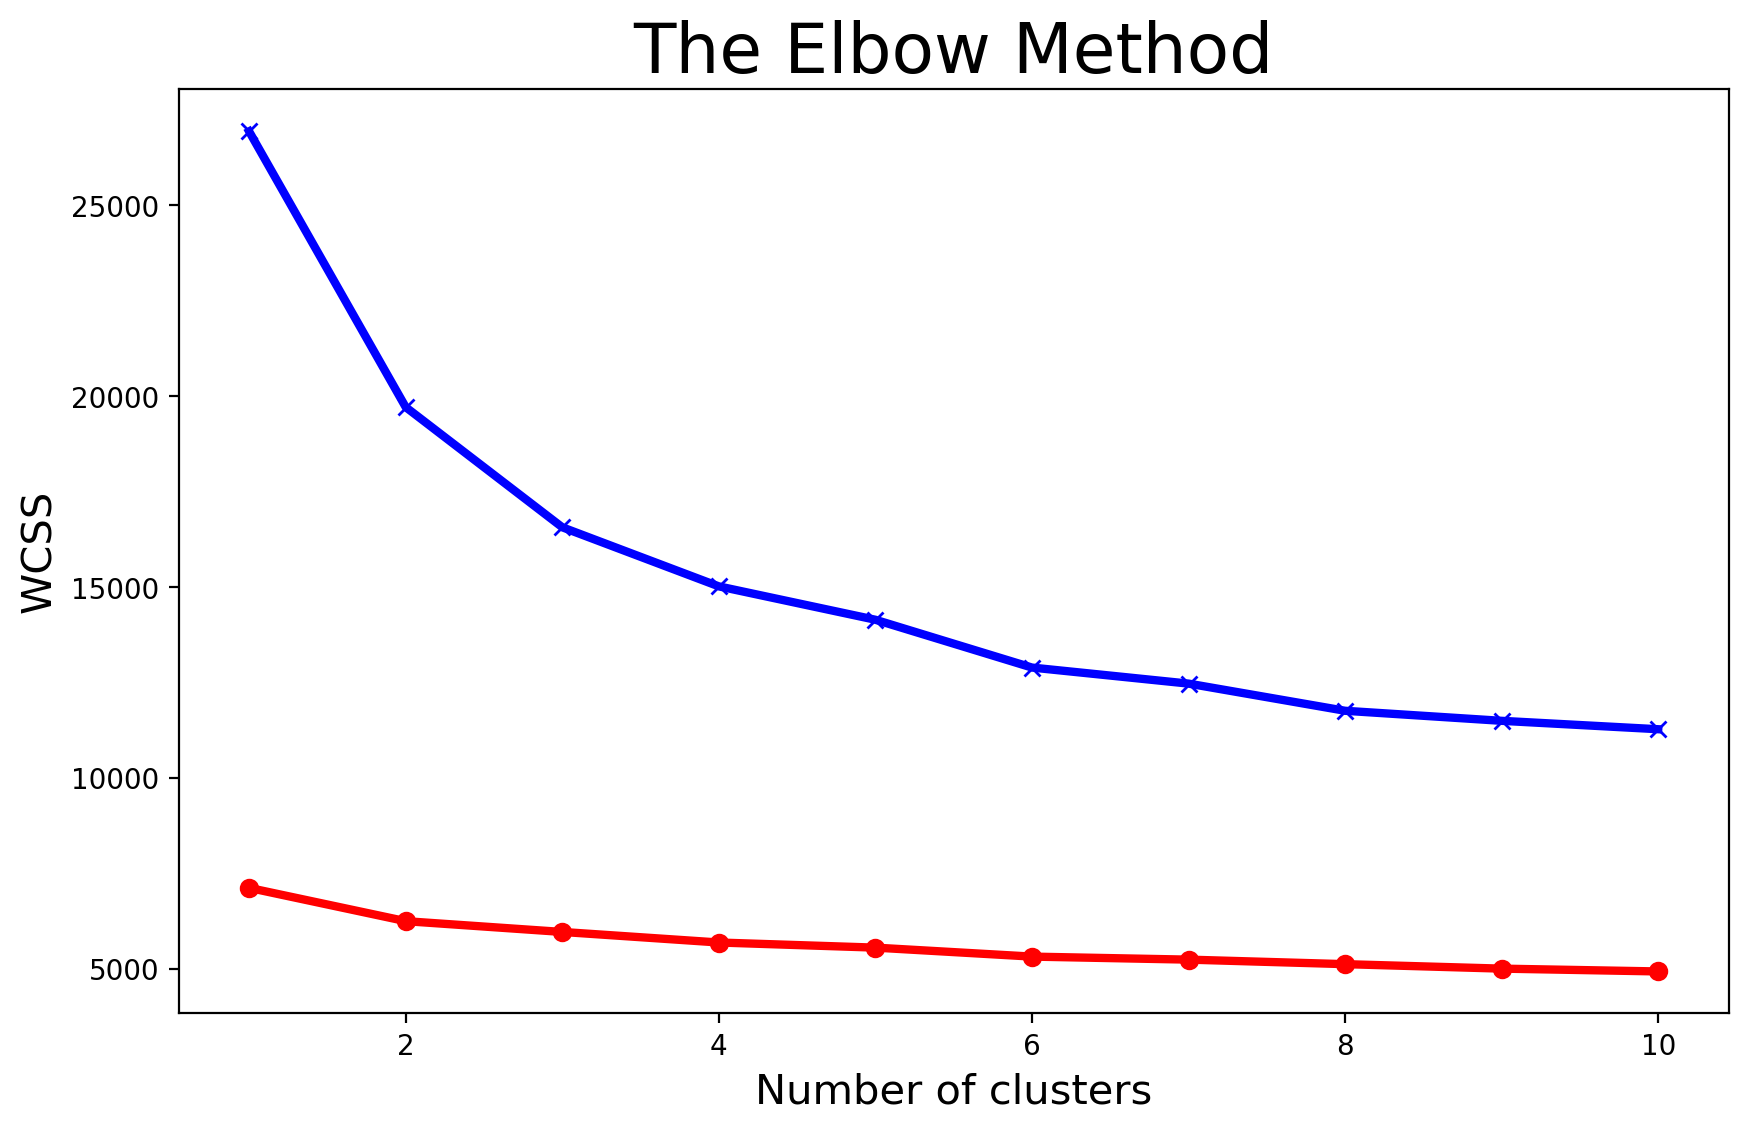

In [45]:
# Line plot to show the " Pick optimal number of clusters using Elbow method" of the unreduced and reduced dimension Kmeans features
plt.figure(figsize = (10,6))
plt.plot(range(1, k + 1), wcss_vals_original, lw = 3, marker='o', color='r')
plt.plot(range(1, k + 1), wcss_vals_reduced, lw = 3, marker='x', color='b')
plt.title('The Elbow Method', fontsize = 25)
plt.xlabel('Number of clusters', fontsize = 15)
plt.ylabel('WCSS', fontsize =15 )
plt.show()

In [46]:
## Apply the resulting optimal k to find new centroids
k_means_model = KMeans(n_clusters=2, random_state= 498)
k_means_model.fit(encoded_data)


KMeans(n_clusters=2, random_state=498)

In [47]:
## Show the centroids shape
print(f"The shape of centroids: {k_means_model.cluster_centers_.shape}")

The shape of centroids: (2, 24)


In [48]:
# Show the clusters shape
cluster_label = k_means_model.labels_
values, counts = np.unique(cluster_label, return_counts=True)

for i in range(len(values)):
    print(f"Cluster: {values[i]}, Count: {counts[i]}")

Cluster: 0, Count: 436
Cluster: 1, Count: 1034


In [49]:
# Show the 'Number of samples" in current consolidated
print(f"The total number of samples: {cluster_label.shape}")

The total number of samples: (1470,)


In [50]:
## Apply PCA to encoded dataset
encoded_x_pca = pca.fit_transform(encoded_data)
encoded_x_pca.shape

(1470, 24)

In [51]:
# Concatenate the clusters to the data
encoded_pca_df = pd.DataFrame({'first_pca': encoded_x_pca[:, 0], 'second_pca': encoded_x_pca[:, 1]})
encoded_pca_df['cluster'] = pd.DataFrame({'cluster': cluster_label})
encoded_pca_df.shape

(1470, 3)

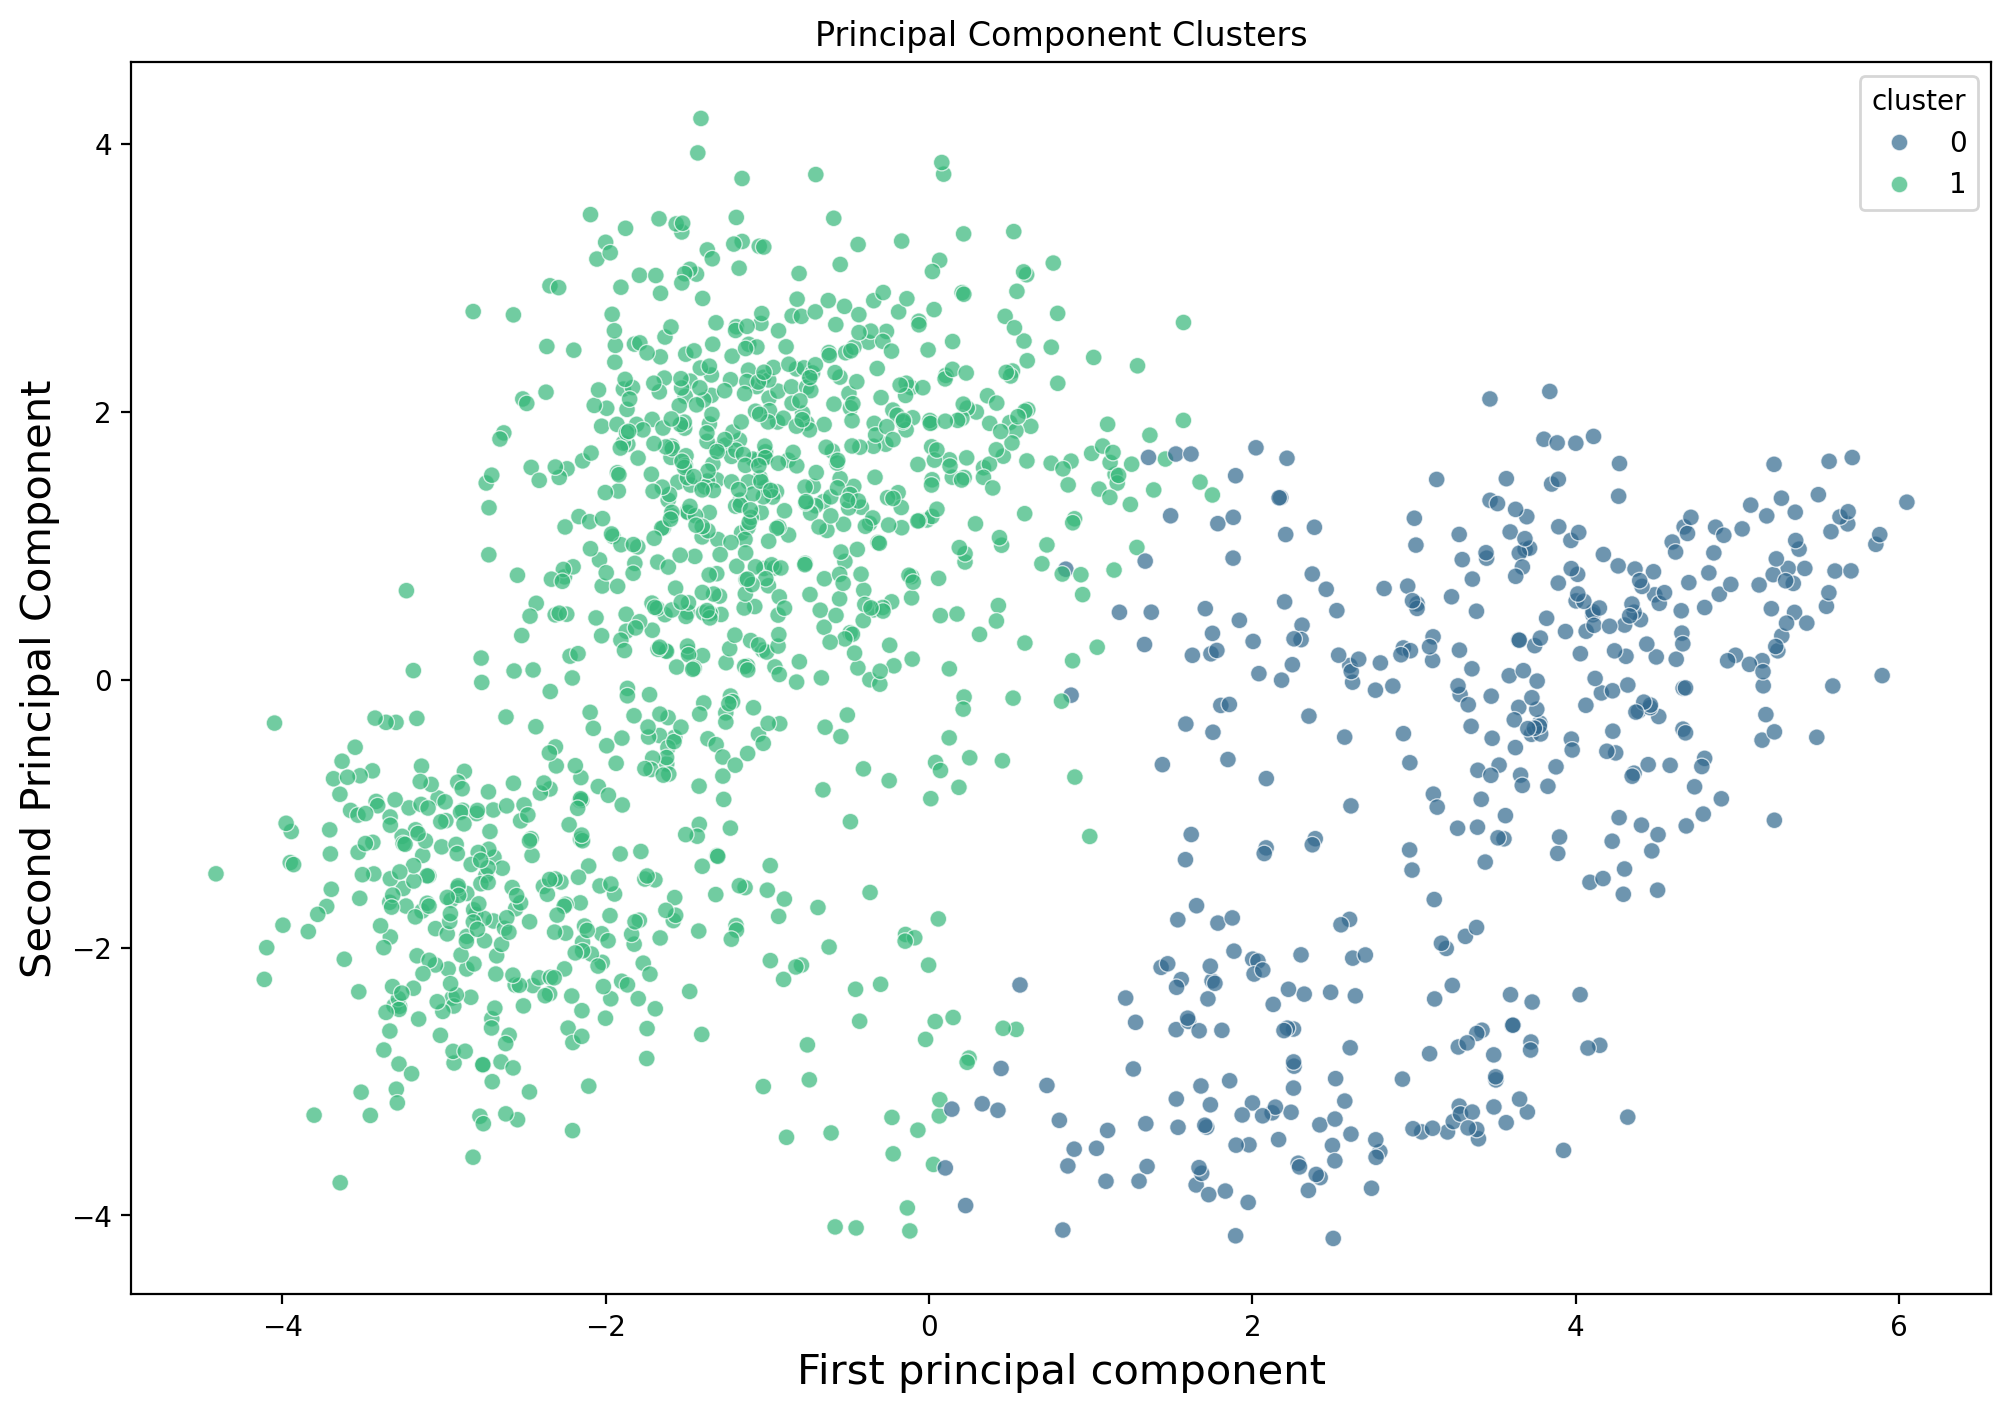

In [52]:
## Plot PCA scatterplot with clusters as the hue
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=encoded_pca_df,
    x='first_pca',
    y='second_pca',
    hue="cluster",
    palette="viridis",
    legend="full",
    alpha=0.7,
)
plt.title('Principal Component Clusters')
plt.xlabel('First principal component', fontsize = 15)
plt.ylabel('Second Principal Component', fontsize = 15)
plt.show()